***Week 3 Jupyter Notebook — Linear Regression 3 Instructions***

Week 3 Jupyter Notebook — Linear Regression 3
Each week, you will apply the concepts of that week to your Integrated Capstone Project’s dataset. In preparation for Milestone One, create a Jupyter Notebook (similar to in Module B, Semester Two) that illustrates these lessons. There are no specific questions to answer in your Jupyter Notebook files in this course; your general goal is to analyze your data, using the methods you have learned about in this course and in this program, and draw interesting conclusions. 

For Week 3, include concepts such as linear regression with forward and backward selection, PCR, and PLSR. Complete your Jupyter Notebook homework by 11:59 pm ET on Sunday. 

# Week 3: Forward/backward selection, PCR, and PLSR

**Assignment coverage:** forward selection; backward selection; grouped categorical predictors; principal component regression (PCR); partial least squares regression (PLSR); component tuning; held-out comparison; conclusions.

**Expanded coverage:** this notebook applies the weekly methods independently to all three CSV files in `DATA`. Each dataset has its own response, preparation, model selection, diagnostics, and conclusions. Metrics with different outcomes or units must not be ranked against one another.

## Results across all three datasets

- **accepted_2007_to_2018Q4.csv**: Forward selection; test RMSE **3.084 percentage points**, MAE **2.441 percentage points**, R² **0.485**, test n = **4,800**. Development-mean baseline RMSE: **4.299 percentage points**.
- **Loan_Default.csv**: Forward selection; test RMSE **0.448 percentage points**, MAE **0.356 percentage points**, R² **0.338**, test n = **4,800**. Development-mean baseline RMSE: **0.551 percentage points**.
- **bank_customers.csv**: Full OLS; test RMSE **10.817 years**, MAE **8.857 years**, R² **-0.083**, test n = **8**. Development-mean baseline RMSE: **12.141 years**.

Each dataset now has its own full application of this week's required methods. LendingClub models issued rates in a 2015 cohort; Loan_Default models observed rates in a heavily selected subset; bank_customers models historical account tenure. Their errors use different populations and, for the bank file, different units. The small bank holdout is a method demonstration, not a reliable performance claim. The dataset-specific conclusions above explain the observed selection, shrinkage, or component tradeoff. No result establishes causality or future-cohort validity.

The prose describes this saved run. If inputs or parameters change, rerun all code and revise the narrative to match.

## A. accepted_2007_to_2018Q4.csv — independent analysis

## Context & methods

**Question:** How well can application and contract attributes explain the issued
interest rate of a loan, and what does this week's method change?
The response is `int_rate`, measured in percent; prediction errors are reported in
**percentage points (pp)**. A rate of 12 is 12%, not 0.12%.

**Source:** `DATA/accepted_2007_to_2018Q4.csv`. The analysis takes a reproducible,
uniform sample of 24,000 eligible loans issued in **2015**, scanning the whole CSV
in chunks. One origination year limits changes in lending policy across years.
The model explains rates on accepted loans; it does not estimate default risk,
approval probability, or causal effects. Weeks 1–3 deliberately reuse the same
sample and 60%/20%/20% training/validation/test partitions for comparability.

### Key assumptions

- Rows represent distinct loans; unique sampled loan IDs are checked. The file
  does not provide a usable borrower-group design here, so repeat-borrower
  dependence remains possible. A random split evaluates same-cohort performance,
  not future-year generalization.
- `int_rate` must be observed and in (0, 100]. Missing predictors are imputed using
  training data. Large positive incomes and utilization over 100 are retained;
  they are not silently removed. Log transforms reduce income/amount skew.
- Grade, subgrade, installment, funded amounts, payment/recovery fields, and later
  loan status are excluded from predictors: some directly encode pricing, are
  redundant, or occur after origination. Contract term and verification status
  make this an **issued-rate explanation**, not a pre-application quote model.
- Categorical values use one-hot indicators with a dropped reference level.
  Continuous variables are standardized inside each fitted pipeline. Employment
  duration is approximate and top-coded. No external data dictionary/rubric was
  included, so undocumented coding and units are not invented.
- Hyperparameters and model families are chosen without test outcomes. Every
  learned transformation is fitted inside the appropriate training/CV partition.
  The final test is opened once per notebook; the three notebooks are related
  instructional comparisons, not independent confirmatory experiments.

**Run instructions:** Install `requirements-notebooks.txt`, select a Python
kernel, and use **Restart Kernel → Run All**. Each notebook is self-contained and
reads the original CSV; no earlier notebook or temporary cache is required.

### 1. Set up a reproducible Python environment

Imports, a fixed random seed, readable charts, and explicit package versions make the analysis auditable.

In [1]:
from pathlib import Path
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import sklearn
from IPython.display import display, Markdown
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

# A fixed seed and bounded numerical threads make the workflow repeatable.
SEED = 42
thread_limit = threadpool_limits(limits=1)
warnings.filterwarnings('error', category=ConvergenceWarning)
pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'figure.dpi': 115,
                     'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.18, 'axes.axisbelow': True})
BLUE, ORANGE, GRAY = '#245E91', '#B96520', '#50545A'

# Support opening from the repository itself or its parent workspace.
data_candidates = [Path.cwd() / 'DATA',
                   Path.cwd() / 'Data-Science-Capstone-DX799' / 'DATA']
DATA_DIR = next((p for p in data_candidates if p.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Open this notebook from the repository or its parent; DATA is required.')
display(pd.Series({'Python': platform.python_version(), 'pandas': pd.__version__,
                   'NumPy': np.__version__, 'scikit-learn': sklearn.__version__,
                   'SciPy': scipy.__version__, 'seed': SEED}, name='Execution environment'))

Python          3.13.5
pandas           3.0.0
NumPy            2.4.1
scikit-learn     1.8.0
SciPy           1.17.0
seed                42
Name: Execution environment, dtype: object

### 2. Load and reconcile the 2015 lending cohort

The large CSV is streamed in chunks. Random priorities give every eligible row the same inclusion probability.

In [2]:
SOURCE = DATA_DIR / 'accepted_2007_to_2018Q4.csv'
COHORT_YEAR = '2015'
SAMPLE_SIZE = 24_000
USECOLS = ['id', 'loan_amnt', 'funded_amnt', 'int_rate', 'term', 'annual_inc',
           'fico_range_low', 'fico_range_high', 'dti', 'revol_util', 'emp_length',
           'earliest_cr_line', 'open_acc', 'home_ownership', 'verification_status',
           'purpose', 'issue_d']
rng = np.random.default_rng(SEED)
sample = pd.DataFrame()
source_rows = cohort_rows = eligible_rows = 0

# Read the complete file in chunks, then retain the smallest independent random
# priorities. This is a uniform sample without replacement, not the first 24,000
# rows (the source is not randomly ordered). Memory stays bounded.
for chunk in pd.read_csv(SOURCE, usecols=USECOLS, chunksize=150_000, low_memory=False):
    source_rows += len(chunk)
    cohort = chunk.loc[chunk['issue_d'].astype('str').str.endswith(COHORT_YEAR)].copy()
    cohort_rows += len(cohort)
    rate = pd.to_numeric(cohort['int_rate'], errors='coerce')
    cohort = cohort.loc[rate.gt(0) & rate.le(100)].copy()
    eligible_rows += len(cohort)
    if not cohort.empty:
        cohort['_priority'] = rng.random(len(cohort))
        sample = pd.concat([sample, cohort.nsmallest(SAMPLE_SIZE, '_priority')])
        sample = sample.nsmallest(SAMPLE_SIZE, '_priority')
sample = sample.drop(columns='_priority').reset_index(drop=True)
assert len(sample) == SAMPLE_SIZE and sample['id'].notna().all()
assert sample['id'].is_unique, 'Repeated loan IDs require a grouped split.'
assert sample['int_rate'].between(0, 100, inclusive='right').all()
display(pd.Series({'source CSV rows': source_rows, '2015 rows': cohort_rows,
                   'eligible positive-rate rows': eligible_rows,
                   'excluded missing/invalid rates': cohort_rows - eligible_rows,
                   'sampled loans': len(sample), 'source bytes': SOURCE.stat().st_size},
                  name='Source and cohort reconciliation'))
# Exclude identifiers and free-text personal information from displayed records.
display(sample[['loan_amnt', 'int_rate', 'term', 'annual_inc',
                'fico_range_low', 'dti', 'home_ownership']].head())

source CSV rows                      2260701
2015 rows                             421095
eligible positive-rate rows           421095
excluded missing/invalid rates             0
sampled loans                          24000
source bytes                      1675133810
Name: Source and cohort reconciliation, dtype: int64

,loan_amnt,int_rate,term,annual_inc,fico_range_low,dti,home_ownership
0,"20,225.0000",18.8400,60 months,"90,000.0000",685.0000,12.5200,RENT
1,"35,000.0000",7.8900,36 months,"140,000.0000",775.0000,8.7200,MORTGAGE
2,"10,000.0000",12.3900,36 months,"74,000.0000",695.0000,13.3500,RENT
3,"21,275.0000",18.4900,60 months,"210,000.0000",695.0000,3.3500,RENT
4,"31,175.0000",11.4900,36 months,"185,000.0000",695.0000,13.8600,RENT


### 3. Engineer interpretable features and reserve evaluation data

Only row-wise feature construction happens before splitting. The final test outcomes are not inspected during model selection.

In [3]:
# These are row-wise transformations with fixed rules, so they do not learn from
# validation/test data. Imputation, scaling, and encoding are fitted later.
X = pd.DataFrame(index=sample.index)
X['log_loan_amount'] = np.log1p(sample['loan_amnt'].where(sample['loan_amnt'] > 0))
X['log_annual_income'] = np.log1p(sample['annual_inc'].where(sample['annual_inc'] >= 0))
X['fico_mid'] = (sample['fico_range_low'] + sample['fico_range_high']) / 2
X['dti'] = sample['dti'].where(sample['dti'] >= 0)
X['revol_util'] = sample['revol_util'].where(sample['revol_util'] >= 0)
# '< 1 year' is represented by 0.5; '10+ years' by 10 (a top-coded value).
employment_map = {'< 1 year': 0.5, '1 year': 1, '10+ years': 10}
employment_map.update({f'{i} years': i for i in range(2, 10)})
X['employment_years'] = sample['emp_length'].map(employment_map)
issued = pd.to_datetime(sample['issue_d'], format='%b-%Y', errors='coerce')
first_credit = pd.to_datetime(sample['earliest_cr_line'], format='%b-%Y', errors='coerce')
X['credit_history_years'] = ((issued - first_credit).dt.days / 365.25).clip(lower=0)
X['open_acc'] = sample['open_acc'].where(sample['open_acc'] >= 0)
NUMERIC = list(X.columns)
CATEGORICAL = ['term', 'home_ownership', 'verification_status', 'purpose']
for name in CATEGORICAL:
    X[name] = sample[name].str.strip().astype(object).where(sample[name].notna(), np.nan)
y = sample['int_rate'].astype(float)

# Reserve the test partition before any data-driven model selection.
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=SEED)
assert not (set(X_train.index) & set(X_valid.index) or
            set(X_dev.index) & set(X_test.index))
assert len(X_train) + len(X_valid) + len(X_test) == len(sample)
display(pd.Series({'training': len(X_train), 'validation': len(X_valid),
                   'test (sealed until final evaluation)': len(X_test)}, name='Partition sizes'))
display(X_train.isna().mean().mul(100).sort_values(ascending=False)
        .rename('Training missing (%)').to_frame())

training                                14400
validation                               4800
test (sealed until final evaluation)     4800
Name: Partition sizes, dtype: int64

,Training missing (%)
employment_years,5.7708
revol_util,0.0347
log_loan_amount,0.0000
log_annual_income,0.0000
fico_mid,0.0000
dti,0.0000
credit_history_years,0.0000
open_acc,0.0000
term,0.0000
home_ownership,0.0000


### 4. Define preprocessing and evaluation helpers

Median imputation and scaling occur inside the estimator pipeline. Dummy encoding keeps categorical predictors distinct from continuous predictors.

In [4]:
class SelectedPolynomialTerms(TransformerMixin, BaseEstimator):
    """Append selected quadratic/interaction terms to standardized numeric data."""
    def __init__(self, mode='linear', fico_index=2, dti_index=3):
        self.mode = mode
        self.fico_index = fico_index
        self.dti_index = dti_index

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        result = np.asarray(X)
        fico, dti = result[:, self.fico_index], result[:, self.dti_index]
        if self.mode in ('quadratic', 'interaction'):
            result = np.column_stack([result, fico ** 2, dti ** 2])
        if self.mode == 'interaction':
            result = np.column_stack([result, fico * dti])
        return result

    def get_feature_names_out(self, input_features=None):
        names = list(input_features)
        if self.mode in ('quadratic', 'interaction'):
            names += ['fico_mid_squared', 'dti_squared']
        if self.mode == 'interaction':
            names += ['fico_mid_x_dti']
        return np.asarray(names, dtype=object)

def make_preprocessor(mode='linear', numeric=None, categorical=None):
    """Fit all learned preparation inside a pipeline or cross-validation fold."""
    numeric = NUMERIC if numeric is None else numeric
    categorical = CATEGORICAL if categorical is None else categorical
    transformers = []
    if numeric:
        numeric_steps = [('impute', SimpleImputer(strategy='median')),
                         ('standardize', StandardScaler())]
        if mode != 'linear':
            numeric_steps += [('terms', SelectedPolynomialTerms(mode=mode))]
        transformers.append(('numeric', Pipeline(numeric_steps), numeric))
    if categorical:
        transformers.append(('categorical', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def regression_metrics(actual, predicted):
    predicted = np.asarray(predicted).ravel()
    return {'RMSE (pp)': np.sqrt(mean_squared_error(actual, predicted)),
            'MAE (pp)': mean_absolute_error(actual, predicted),
            'R²': r2_score(actual, predicted)}

CV = KFold(n_splits=3, shuffle=True, random_state=SEED)

## Selection and component logic

Forward selection starts with no predictors and adds the raw feature group
that gives the lowest cross-validated RMSE at each step. Backward selection
starts with all groups and removes one group at a time. The best CV point on
each path chooses its subset size. Each categorical feature is an indivisible
group of dummy columns, so we do not select isolated levels arbitrarily.
These greedy searches need not find the globally best subset. Reusing folds
to search many subsets makes their minimum CV scores optimistic; independent
validation and final test partitions remain essential.

PCR standardizes the encoded design, finds principal components that capture
variance in **X**, and regresses the response on selected components. PLSR
also uses **y** when choosing directions, seeking predictive covariance.
High predictor variance alone need not indicate useful response information.
Both methods must be fitted inside each training fold. PLSR uses `scale=False`
because the preceding pipeline already standardizes the encoded design.

For a clean comparison of selection versus projection, every Week 3 method
starts from the same **additive** candidate features. Week 2's nonlinear
expansion is not mixed into this comparison.

### 5. Search forward and backward over raw feature groups

Cache scores for identical subsets to avoid redundant fits. Within each fold, the candidate pipeline independently learns imputation, scaling, and encoding. All 12 raw groups can enter; no test data are used.

In [5]:
GROUPS = NUMERIC + CATEGORICAL
subset_scores = {}

def subset_pipeline(groups):
    return Pipeline([('prepare', make_preprocessor(
        numeric=[name for name in NUMERIC if name in groups],
        categorical=[name for name in CATEGORICAL if name in groups])),
        ('regress', LinearRegression())])

def score_subset(groups):
    key = tuple(name for name in GROUPS if name in groups)
    if key not in subset_scores:
        estimator = subset_pipeline(key) if key else DummyRegressor()
        errors = -cross_val_score(estimator, X_train, y_train, cv=CV,
                                   scoring='neg_root_mean_squared_error', n_jobs=1)
        subset_scores[key] = (errors.mean(), errors.std(ddof=1))
    return subset_scores[key]

def selection_path(direction):
    chosen = [] if direction == 'forward' else GROUPS.copy()
    path = []
    mean, sd = score_subset(chosen)
    path.append({'groups': chosen.copy(), 'n_groups': len(chosen),
                 'CV RMSE (pp)': mean, 'CV fold SD (pp)': sd, 'change': 'start'})
    while (len(chosen) < len(GROUPS) if direction == 'forward' else len(chosen) > 1):
        alternatives = []
        for name in GROUPS:
            if direction == 'forward' and name not in chosen:
                candidate = chosen + [name]
            elif direction == 'backward' and name in chosen:
                candidate = [item for item in chosen if item != name]
            else:
                continue
            mean, sd = score_subset(candidate)
            alternatives.append((mean, name, candidate, sd))
        mean, name, chosen, sd = min(alternatives, key=lambda item: (item[0], item[1]))
        path.append({'groups': chosen.copy(), 'n_groups': len(chosen),
                     'CV RMSE (pp)': mean, 'CV fold SD (pp)': sd, 'change': name})
    return pd.DataFrame(path)

forward_path = selection_path('forward')
backward_path = selection_path('backward')
forward_groups = forward_path.loc[forward_path['CV RMSE (pp)'].idxmin(), 'groups']
backward_groups = backward_path.loc[backward_path['CV RMSE (pp)'].idxmin(), 'groups']
assert forward_groups and backward_groups
display(forward_path.drop(columns='groups'))
display(backward_path.drop(columns='groups'))
selection_membership = pd.DataFrame({
    'Feature group': GROUPS,
    'Forward selected': [name in forward_groups for name in GROUPS],
    'Backward selected': [name in backward_groups for name in GROUPS]})
display(selection_membership)
print(f'Distinct training-CV subsets evaluated: {len(subset_scores)}')

,n_groups,CV RMSE (pp),CV fold SD (pp),change
0,0,4.3457,0.0376,start
1,1,3.8966,0.0096,term
2,2,3.5306,0.0254,fico_mid
3,3,3.3724,0.0179,purpose
4,4,3.2822,0.0047,verification_status
5,5,3.1935,0.0088,log_annual_income
6,6,3.1680,0.0092,credit_history_years
7,7,3.1392,0.0149,dti
8,8,3.1296,0.0184,log_loan_amount
9,9,3.1277,0.0182,revol_util


,n_groups,CV RMSE (pp),CV fold SD (pp),change
0,12,3.1268,0.0203,start
1,11,3.1263,0.0201,employment_years
2,10,3.1268,0.0192,open_acc
3,9,3.1277,0.0182,home_ownership
4,8,3.1296,0.0184,revol_util
5,7,3.1392,0.0149,log_loan_amount
6,6,3.1680,0.0092,dti
7,5,3.1935,0.0088,credit_history_years
8,4,3.2822,0.0047,log_annual_income
9,3,3.3724,0.0179,verification_status


,Feature group,Forward selected,Backward selected
0,log_loan_amount,True,True
1,log_annual_income,True,True
2,fico_mid,True,True
3,dti,True,True
4,revol_util,True,True
5,employment_years,False,False
6,credit_history_years,True,True
7,open_acc,True,True
8,term,True,True
9,home_ownership,True,True


Distinct training-CV subsets evaluated: 134


### 6. Tune the number of PCR and PLSR components

Tune components using the same training folds. Full encoded dimension is included as a useful benchmark: keeping all nondegenerate components should recover the OLS fitted space, subject to numerical tolerances.

In [6]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
encoded_count = make_preprocessor().fit_transform(X_train).shape[1]
component_grid = sorted(set([k for k in [1, 2, 3, 5, 8, 12, 16, 20, encoded_count]
                              if k <= encoded_count]))
pcr = Pipeline([('prepare', make_preprocessor()), ('scale_all', StandardScaler()),
                ('components', PCA(svd_solver='full')), ('regress', LinearRegression())])
plsr = Pipeline([('prepare', make_preprocessor()), ('scale_all', StandardScaler()),
                 ('regress', PLSRegression(scale=False, max_iter=2000, tol=1e-7))])
pcr_search = GridSearchCV(pcr, {'components__n_components': component_grid}, cv=CV,
                          scoring='neg_root_mean_squared_error', n_jobs=1, error_score='raise')
pls_search = GridSearchCV(plsr, {'regress__n_components': component_grid}, cv=CV,
                          scoring='neg_root_mean_squared_error', n_jobs=1, error_score='raise')
pcr_search.fit(X_train, y_train)
pls_search.fit(X_train, y_train)
pcr_components = pcr_search.best_params_['components__n_components']
pls_components = pls_search.best_params_['regress__n_components']
display(pd.DataFrame({'method': ['PCR', 'PLSR'],
    'selected components': [pcr_components, pls_components],
    'CV RMSE (pp)': [-pcr_search.best_score_, -pls_search.best_score_]}).set_index('method'))

,selected components,CV RMSE (pp)
method,,
PCR,24,3.1268
PLSR,12,3.1268


### 7. Visualize subset and component tradeoffs

The left panel compares greedy paths. The right panel compares prediction error at each latent dimension. PCR variance retained is shown separately because explaining X is different from predicting y.

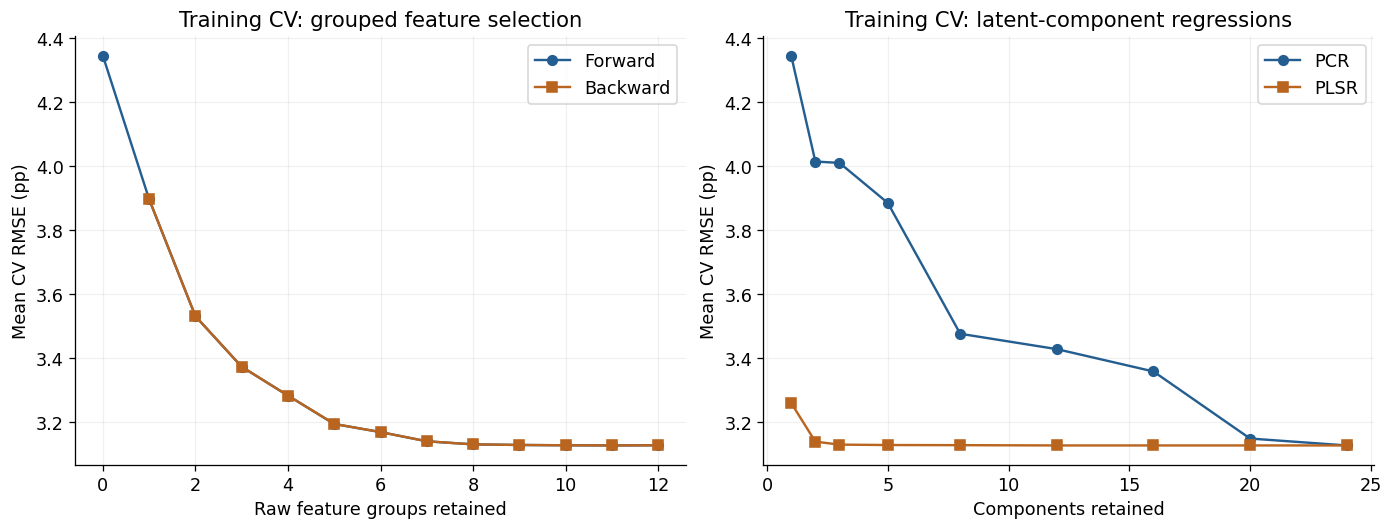

Encoded candidate columns         24.0000
PCR components selected           24.0000
PCR predictor variance retained    1.0000
PLSR components selected          12.0000
Name: Dimension reduction, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
for name, path, color, marker in [('Forward', forward_path, BLUE, 'o'),
                                   ('Backward', backward_path, ORANGE, 's')]:
    ordered = path.sort_values('n_groups')
    axes[0].plot(ordered['n_groups'], ordered['CV RMSE (pp)'],
                 label=name, color=color, marker=marker)
axes[0].set(title='Training CV: grouped feature selection',
            xlabel='Raw feature groups retained', ylabel='Mean CV RMSE (pp)')
axes[0].legend()
for name, search, parameter, color, marker in [
    ('PCR', pcr_search, 'param_components__n_components', BLUE, 'o'),
    ('PLSR', pls_search, 'param_regress__n_components', ORANGE, 's')]:
    result = pd.DataFrame(search.cv_results_)
    axes[1].plot(result[parameter].astype(int), -result['mean_test_score'],
                 label=name, color=color, marker=marker)
axes[1].set(title='Training CV: latent-component regressions',
            xlabel='Components retained', ylabel='Mean CV RMSE (pp)')
axes[1].legend()
plt.show()
variance_retained = pcr_search.best_estimator_.named_steps['components'].explained_variance_ratio_.sum()
display(pd.Series({'Encoded candidate columns': encoded_count,
                   'PCR components selected': pcr_components,
                   'PCR predictor variance retained': variance_retained,
                   'PLSR components selected': pls_components}, name='Dimension reduction'))

Forward selection retained **11** raw groups and backward selection retained **11**. PCR retained **24/24** components, accounting for **100.0%** of standardized predictor variance. PLSR selected **12** components. Whether either method actually reduces dimension is an empirical result; a near-full solution is evidence that aggressive compression costs predictive information in this design.

### 8. Select on validation data and evaluate the final model

Compare all prespecified families on validation loans. Refit the chosen configuration on development data and report its final-test error alongside fixed baselines. Selection paths and component counts are frozen before opening the test set.

In [8]:
candidates = {'All-feature OLS': subset_pipeline(GROUPS),
              'Forward selection': subset_pipeline(forward_groups),
              'Backward selection': subset_pipeline(backward_groups),
              'PCR': clone(pcr_search.best_estimator_),
              'PLSR': clone(pls_search.best_estimator_)}
validation_rows = []
for name, estimator in candidates.items():
    estimator.fit(X_train, y_train)
    validation_rows.append({'model': name,
        'Train RMSE (pp)': regression_metrics(y_train, estimator.predict(X_train))['RMSE (pp)'],
        **regression_metrics(y_valid, estimator.predict(X_valid))})
validation_results = pd.DataFrame(validation_rows).set_index('model')
display(validation_results.sort_values('RMSE (pp)'))
chosen_name = validation_results['RMSE (pp)'].idxmin()
final_names = list(dict.fromkeys([chosen_name, 'All-feature OLS']))
final_models = {name: clone(candidates[name]).fit(X_dev, y_dev) for name in final_names}
test_predictions = {name: np.asarray(model.predict(X_test)).ravel()
                    for name, model in final_models.items()}
test_predictions['Mean baseline'] = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
test_results = pd.DataFrame({name: regression_metrics(y_test, prediction)
                            for name, prediction in test_predictions.items()}).T
display(test_results.rename_axis('Final test model'))
# Independent algebraic check: full-rank PCR should match additive OLS.
full_pcr = clone(pcr).set_params(components__n_components=encoded_count).fit(X_train, y_train)
pcr_ols_gap = np.max(np.abs(full_pcr.predict(X_valid) - candidates['All-feature OLS'].predict(X_valid)))
assert pcr_ols_gap < 1e-6, 'Full PCR and OLS disagree; inspect rank or preprocessing.'
print(f'Maximum validation prediction difference, full PCR vs OLS: {pcr_ols_gap:.2e} pp')

,Train RMSE (pp),RMSE (pp),MAE (pp),R²
model,,,,
Forward selection,3.1175,3.1199,2.4626,0.4783
Backward selection,3.1175,3.1199,2.4626,0.4783
PLSR,3.1174,3.1204,2.4631,0.4781
All-feature OLS,3.1174,3.1205,2.4631,0.4781
PCR,3.1174,3.1205,2.4631,0.4781


,RMSE (pp),MAE (pp),R²
Final test model,,,
Forward selection,3.0842,2.4406,0.4850
All-feature OLS,3.0842,2.4405,0.4850
Mean baseline,4.2988,3.4020,-0.0004


Maximum validation prediction difference, full PCR vs OLS: 6.39e-14 pp


### Dataset conclusions — accepted_2007_to_2018Q4.csv

1. **Forward selection** achieved the lowest validation RMSE. Final-test RMSE was **3.084 pp**, MAE **2.441 pp**, and R² **0.485**. The all-feature OLS test RMSE was **3.084 pp**.
2. Forward/backward selection retained **11/11** of **12** groups, with **11** groups in common. These are greedy predictive selections, not significance tests or proof that omitted predictors are irrelevant.
3. PCR selected **24** components and PLSR **12** out of **24** encoded features. PCR retained **100.0%** of predictor variance. Response-aware directions and variance-maximizing directions answer different optimization questions.
4. Full-component PCR reproduced OLS validation predictions to within **6.39e-14 pp**, confirming the fitted-space relationship. A large component count or feature count is a valid outcome, not a failed assignment.

**Capstone implication:** favor a simpler representation only when the observed loss in prediction is acceptable. Stepwise CV scores are affected by searching many subsets; the independent validation/test comparison supports the reported performance. Future-year evaluation and selection-stability analysis remain necessary before deployment.

### Shared tools for the additional independent analyses

Reuse transparent pipeline-building code, not fitted objects or results. Dataset B and Dataset C each reload their own file, redefine the response, reserve their own evaluation data, and fit every method afresh.

In [9]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss,
    brier_score_loss, accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

class ExtraTerms(TransformerMixin, BaseEstimator):
    """Retain parents; append numeric squares and prespecified interactions."""
    def __init__(self, numeric_count=1, mode='linear'):
        self.numeric_count = numeric_count
        self.mode = mode

    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        values = np.asarray(X)
        pieces = [values]
        if self.mode in ('quadratic', 'interaction'):
            pieces.append(values[:, :self.numeric_count] ** 2)
        if self.mode == 'interaction':
            # Interact the first continuous feature with each remaining numeric
            # predictor and category indicator. Do not square 0/1 indicators.
            pieces.append(values[:, [0]] * values[:, 1:])
        return np.column_stack(pieces)

    def get_feature_names_out(self, input_features=None):
        names = list(input_features)
        result = names.copy()
        if self.mode in ('quadratic', 'interaction'):
            result += [f'{name} squared' for name in names[:self.numeric_count]]
        if self.mode == 'interaction':
            result += [f'{names[0]} × {name}' for name in names[1:]]
        return np.asarray(result, dtype=object)

def extra_preprocessor(numeric, categorical, scaler='standard'):
    """No preparation is learned from validation/test rows."""
    scalers = {'standard': StandardScaler(), 'minmax': MinMaxScaler(),
               'robust': RobustScaler(), 'none': None}
    transformers = []
    if numeric:
        steps = [('impute', SimpleImputer(strategy='median'))]
        if scalers[scaler] is not None:
            steps.append(('scale', scalers[scaler]))
        transformers.append(('num', Pipeline(steps), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
        ]), categorical))
    return ColumnTransformer(transformers, verbose_feature_names_out=False)

def extra_regressor(numeric, categorical, mode='linear', estimator=None, scale_all=False):
    steps = [('prepare', extra_preprocessor(numeric, categorical)),
             ('terms', ExtraTerms(len(numeric), mode))]
    if scale_all:
        steps.append(('scale_all', StandardScaler()))
    steps.append(('model', LinearRegression() if estimator is None else estimator))
    return Pipeline(steps)

def extra_split(X, y, groups=None, classification=False):
    """Use a row split for loans and account-group separation for bank records."""
    if groups is None:
        development, test = train_test_split(np.arange(len(X)), test_size=0.20,
            random_state=SEED, stratify=y if classification else None)
        train, valid = train_test_split(development, test_size=0.25, random_state=SEED,
            stratify=y.iloc[development] if classification else None)
        cv = (StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
              if classification else KFold(n_splits=3, shuffle=True, random_state=SEED))
        folds = list(cv.split(X.iloc[train], y.iloc[train]))
    else:
        development, test = next(GroupShuffleSplit(n_splits=1, test_size=0.20,
            random_state=SEED).split(X, y, groups))
        train_local, valid_local = next(GroupShuffleSplit(n_splits=1, test_size=0.25,
            random_state=SEED).split(X.iloc[development], y.iloc[development], groups.iloc[development]))
        train, valid = development[train_local], development[valid_local]
        # Do not split records from the same account across CV folds either.
        folds = list(GroupKFold(n_splits=3).split(X.iloc[train], y.iloc[train], groups.iloc[train]))
        sets = [set(groups.iloc[index]) for index in [train, valid, test]]
        assert not (sets[0] & sets[1] or sets[0] & sets[2] or sets[1] & sets[2])
    assert len(set(train) | set(valid) | set(test)) == len(X)
    if classification:
        for index in [train, valid, test]:
            assert y.iloc[index].nunique() == 2, 'Both classes are required in every evaluation split.'
        for fit, holdout in folds:
            assert y.iloc[train].iloc[fit].nunique() == 2
            assert y.iloc[train].iloc[holdout].nunique() == 2
    return train, valid, test, development, folds

def extra_metrics(actual, prediction):
    prediction = np.asarray(prediction).ravel()
    return {'RMSE': np.sqrt(mean_squared_error(actual, prediction)),
            'MAE': mean_absolute_error(actual, prediction), 'R²': r2_score(actual, prediction)}

def extra_vif(frame):
    values = StandardScaler().fit_transform(frame)
    rows = []
    for j, name in enumerate(frame.columns):
        if np.std(values[:, j]) < 1e-12:
            value = np.inf
        elif len(frame.columns) == 1:
            value = 1.0
        else:
            r_squared = LinearRegression().fit(np.delete(values, j, axis=1), values[:, j]).score(
                np.delete(values, j, axis=1), values[:, j])
            value = np.inf if 1 - r_squared < 1e-10 else 1 / (1 - r_squared)
        rows.append({'feature': name, 'VIF': value})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

# Store results separately so later sections cannot overwrite another dataset's evidence.
dataset_results = []

### Preserve Dataset A’s verified results

Keep a separate named result record before beginning another dataset.

In [10]:
primary_scores = test_results.loc[chosen_name]
dataset_results.append({'dataset':'accepted_2007_to_2018Q4.csv','outcome':'issued interest rate',
    'unit':'percentage points','training n':len(y_train),'test n':len(y_test),'model':chosen_name,
    'RMSE':primary_scores['RMSE (pp)'],'MAE':primary_scores['MAE (pp)'],'R²':primary_scores['R²'],
    'baseline RMSE':test_results.loc['Mean baseline','RMSE (pp)']})

## B. Loan_Default.csv — independent analysis

**Response:** observed positive `rate_of_interest`; errors are in percentage points.
Use a reproducible random sample of up to 24,000 eligible records. Predictors include
logged loan amount/income, credit score, term, LTV, DTI, loan type, loan purpose, and
occupancy. Status, rate spread, upfront charges, IDs, and duplicated encodings are excluded.

**Selection limitation:** pricing is missing for nearly every Status 1 record.
Restricting to observed rates therefore changes the population substantially; it cannot
describe pricing for excluded records or predict default. The original status labels
and feature timing are not documented. LTV extremes are retained and their potential
influence is diagnosed rather than silently winsorized using evaluation data.

The same eligible sample, predictors, and partitions are reused across Weeks 1–3.
Each new section fits its own preprocessing, models, and evaluation from this CSV.

### B1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [11]:
dataset_name = 'Loan_Default.csv'
outcome_label, outcome_unit = 'observed interest rate', 'percentage points'
response_axis = 'Interest rate (%)'
source_frame = pd.read_csv(DATA_DIR / dataset_name)
assert source_frame['ID'].is_unique and source_frame['ID'].notna().all()
rates = pd.to_numeric(source_frame['rate_of_interest'], errors='coerce')
eligible = rates.gt(0) & rates.le(100)
loan_missingness = pd.crosstab(source_frame['Status'], rates.isna()).rename(
    columns={False: 'Rate observed', True: 'Rate missing'})
display(loan_missingness)
frame = source_frame.loc[eligible].sample(n=min(24_000, int(eligible.sum())), random_state=SEED).copy()
frame = frame.reset_index(drop=True)
display(pd.Series({'CSV records': len(source_frame), 'valid positive-rate records': eligible.sum(),
    'excluded records': (~eligible).sum(), 'sampled records': len(frame),
    'Status 1 share in eligible population': source_frame.loc[eligible, 'Status'].mean()}, name='Rate cohort'))
X = pd.DataFrame({
    'log_loan_amount': np.log1p(frame['loan_amount'].where(frame['loan_amount'] > 0)),
    'log_income': np.log1p(frame['income'].where(frame['income'] >= 0)),
    'Credit_Score': frame['Credit_Score'], 'term': frame['term'],
    'LTV': frame['LTV'].where(frame['LTV'] >= 0), 'dtir1': frame['dtir1']})
numeric = list(X.columns)
categorical = ['loan_type', 'loan_purpose', 'occupancy_type']
for name in categorical:
    X[name] = frame[name].astype(object).where(frame[name].notna(), np.nan)
y = frame['rate_of_interest'].astype(float)
groups = None

rate_of_interest,Rate observed,Rate missing
Status,,
0,112031,0
1,200,36439


CSV records                             148,670.0000
valid positive-rate records             112,230.0000
excluded records                         36,440.0000
sampled records                          24,000.0000
Status 1 share in eligible population         0.0018
Name: Rate cohort, dtype: float64

### B2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [12]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=False)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean
training,14400,4.0353
validation,4800,4.0478
test,4800,4.0569


,Training missing (%)
log_loan_amount,0.0000
log_income,7.4028
Credit_Score,0.0000
term,0.0000
LTV,0.0069
dtir1,7.2917
loan_type,0.0000
loan_purpose,0.1111
occupancy_type,0.0000


### B3. Explore this dataset’s training response

Show the response distribution and its relationship with the first continuous predictor. Large-loan samples use translucent points; the bank plot displays every training record. These associations do not establish causation.

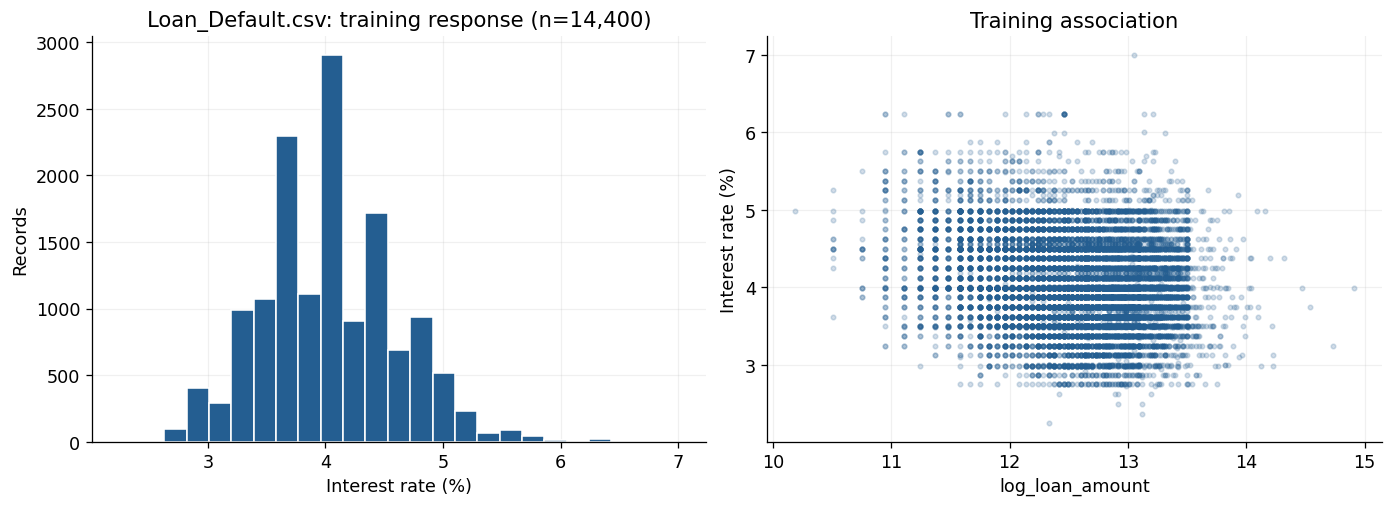

,Training response
count,"14,400.0000"
mean,4.0353
std,0.5600
min,2.2500
25%,3.6250
50%,3.9900
75%,4.3750
max,7.0000


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
axes[0].hist(y_train, bins=min(25, max(5, len(y_train)//3)), color=BLUE, edgecolor='white')
axes[0].set(title=f'{dataset_name}: training response (n={len(y_train):,})',
            xlabel=response_axis, ylabel='Records')
axes[1].scatter(X_train[numeric[0]], y_train, s=20 if len(y_train)<100 else 8,
                alpha=0.8 if len(y_train)<100 else 0.2, color=BLUE)
axes[1].set(title='Training association', xlabel=numeric[0],
            ylabel=response_axis)
plt.show()
display(y_train.describe().rename('Training response').to_frame())

### B4. Run forward and backward selection on this dataset

Repeat both greedy searches on raw predictor groups, keeping all levels of a categorical predictor together. Select the best subset size on training CV. Reusing CV folds during subset search can make its minimum error optimistic; validation and test partitions remain separate.

In [14]:
feature_groups = numeric + categorical
cache = {}
def subset_model(names):
    return extra_regressor([name for name in numeric if name in names],
                           [name for name in categorical if name in names])
def subset_score(names):
    key = tuple(name for name in feature_groups if name in names)
    if key not in cache:
        estimator = subset_model(key) if key else DummyRegressor()
        cache[key] = -cross_val_score(estimator,X_train,y_train,cv=folds,
            scoring='neg_root_mean_squared_error',error_score='raise').mean()
    return cache[key]
def greedy_path(direction):
    selected = [] if direction=='forward' else feature_groups.copy()
    rows = [{'groups': selected.copy(),'n_groups':len(selected),'CV RMSE':subset_score(selected)}]
    while (len(selected)<len(feature_groups) if direction=='forward' else len(selected)>1):
        alternatives = []
        for name in feature_groups:
            if direction=='forward' and name not in selected:
                candidate = selected+[name]
            elif direction=='backward' and name in selected:
                candidate = [item for item in selected if item!=name]
            else:
                continue
            alternatives.append((subset_score(candidate),name,candidate))
        score,_,selected = min(alternatives,key=lambda item:(item[0],item[1]))
        rows.append({'groups':selected.copy(),'n_groups':len(selected),'CV RMSE':score})
    return pd.DataFrame(rows)
forward = greedy_path('forward')
backward = greedy_path('backward')
forward_names = forward.loc[forward['CV RMSE'].idxmin(),'groups']
backward_names = backward.loc[backward['CV RMSE'].idxmin(),'groups']
display(forward.drop(columns='groups'))
display(backward.drop(columns='groups'))
display(pd.DataFrame({'feature group':feature_groups,
    'forward selected':[name in forward_names for name in feature_groups],
    'backward selected':[name in backward_names for name in feature_groups]}))

,n_groups,CV RMSE
0,0,0.5599
1,1,0.5265
2,2,0.5055
3,3,0.4868
4,4,0.4754
5,5,0.4641
6,6,0.4567
7,7,0.4543
8,8,0.4517
9,9,0.4517


,n_groups,CV RMSE
0,9,0.4517
1,8,0.4517
2,7,0.4543
3,6,0.4567
4,5,0.4641
5,4,0.4754
6,3,0.4868
7,2,0.5055
8,1,0.5265


,feature group,forward selected,backward selected
0,log_loan_amount,True,True
1,log_income,True,True
2,Credit_Score,False,False
3,term,True,True
4,LTV,True,True
5,dtir1,True,True
6,loan_type,True,True
7,loan_purpose,True,True
8,occupancy_type,True,True


### B5. Fit and tune PCR and PLSR on this dataset

PCR chooses directions using X variance; PLSR also uses y. Standardization and the component transform are fitted afresh within each CV fold. The grid respects the smallest training-fold dimension and sample size, which matters especially for the small bank dataset.

In [15]:
dimension = extra_preprocessor(numeric,categorical).fit_transform(X_train).shape[1]
fold_limit = min(min(extra_preprocessor(numeric,categorical).fit_transform(X_train.iloc[fit]).shape[1],
                     len(fit)-1) for fit,_ in folds)
component_grid = list(range(1,min(dimension,fold_limit)+1))
pcr = Pipeline([('prepare',extra_preprocessor(numeric,categorical)),('scale_all',StandardScaler()),
                ('components',PCA(svd_solver='full')),('model',LinearRegression())])
plsr = Pipeline([('prepare',extra_preprocessor(numeric,categorical)),('scale_all',StandardScaler()),
                 ('model',PLSRegression(scale=False,max_iter=2000,tol=1e-7))])
pcr_search = GridSearchCV(pcr,{'components__n_components':component_grid},cv=folds,
    scoring='neg_root_mean_squared_error',error_score='raise',n_jobs=1).fit(X_train,y_train)
pls_search = GridSearchCV(plsr,{'model__n_components':component_grid},cv=folds,
    scoring='neg_root_mean_squared_error',error_score='raise',n_jobs=1).fit(X_train,y_train)
pcr_k = pcr_search.best_params_['components__n_components']
pls_k = pls_search.best_params_['model__n_components']
variance_retained = pcr_search.best_estimator_.named_steps['components'].explained_variance_ratio_.sum()
display(pd.DataFrame({'method':['PCR','PLSR'],'components':[pcr_k,pls_k],
    'CV RMSE':[-pcr_search.best_score_,-pls_search.best_score_]}))
print(f'PCR retains {variance_retained:.1%} of standardized predictor variance.')

,method,components,CV RMSE
0,PCR,13,0.4517
1,PLSR,13,0.4517


PCR retains 100.0% of standardized predictor variance.


### B6. Compare selection, projection, and full OLS

The additive feature set is common to all five approaches. Validation chooses the family after training-CV tuning. No method is required to beat full OLS; retaining most features/components is a legitimate empirical outcome.

,RMSE,MAE,R²
model,,,
Forward selection,0.4511,0.3522,0.3626
Backward selection,0.4511,0.3522,0.3626
Full OLS,0.4512,0.3522,0.3624
PCR,0.4512,0.3522,0.3624
PLSR,0.4512,0.3522,0.3624


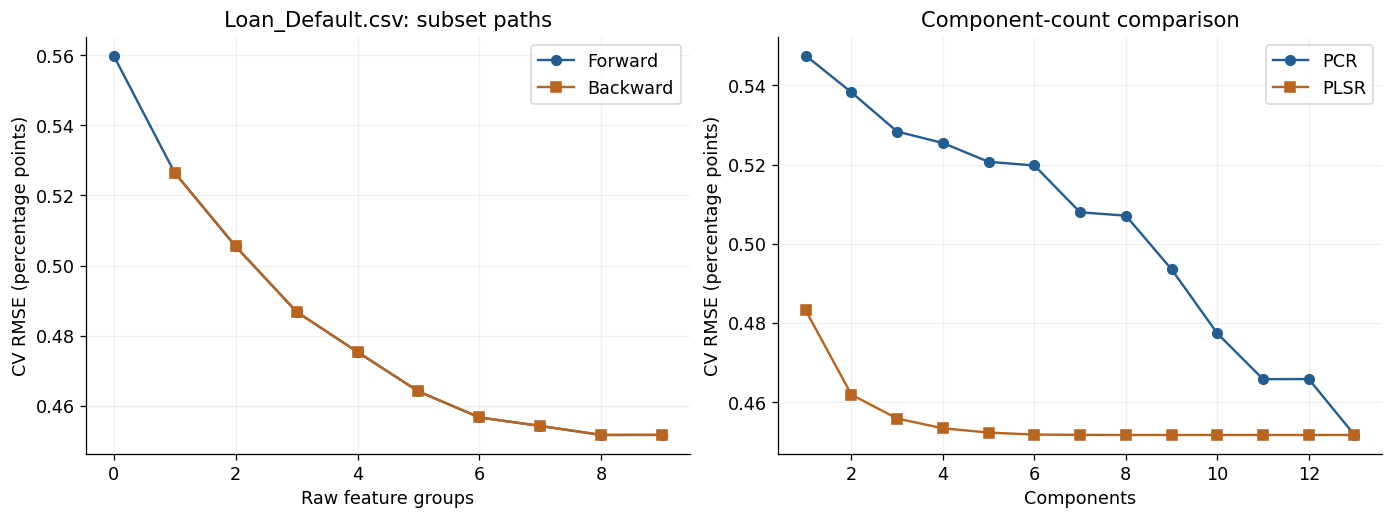

In [16]:
fitted = {
    'Full OLS':subset_model(feature_groups),
    'Forward selection':subset_model(forward_names) if forward_names else DummyRegressor(),
    'Backward selection':subset_model(backward_names),
    'PCR':clone(pcr_search.best_estimator_), 'PLSR':clone(pls_search.best_estimator_)}
rows = []
for name,estimator in fitted.items():
    estimator.fit(X_train,y_train)
    rows.append({'model':name,**extra_metrics(y_valid,estimator.predict(X_valid))})
validation = pd.DataFrame(rows).set_index('model')
display(validation.sort_values('RMSE'))
chosen_name = validation['RMSE'].idxmin()
fig,axes = plt.subplots(1,2,figsize=(12,4.4),layout='constrained')
for name,path,color,marker in [('Forward',forward,BLUE,'o'),('Backward',backward,ORANGE,'s')]:
    ordered = path.sort_values('n_groups')
    axes[0].plot(ordered.n_groups,ordered['CV RMSE'],color=color,marker=marker,label=name)
axes[0].set(title=f'{dataset_name}: subset paths',xlabel='Raw feature groups',ylabel=f'CV RMSE ({outcome_unit})')
axes[0].legend()
for name,search,parameter,color,marker in [('PCR',pcr_search,'param_components__n_components',BLUE,'o'),
                                          ('PLSR',pls_search,'param_model__n_components',ORANGE,'s')]:
    result=pd.DataFrame(search.cv_results_)
    axes[1].plot(result[parameter].astype(int),-result.mean_test_score,color=color,marker=marker,label=name)
axes[1].set(title='Component-count comparison',xlabel='Components',ylabel=f'CV RMSE ({outcome_unit})')
axes[1].legend()
plt.show()
# A fitted-space check, separate from selecting the final method.
full_pcr = clone(pcr).set_params(components__n_components=dimension).fit(X_train,y_train)
pcr_ols_gap = np.max(np.abs(full_pcr.predict(X_valid)-fitted['Full OLS'].predict(X_valid)))
assert pcr_ols_gap<1e-6
method_finding = (f"Forward and backward selection retained **{len(forward_names)}** and "
    f"**{len(backward_names)}** of **{len(feature_groups)}** raw groups. PCR selected **{pcr_k}/{dimension}** "
    f"components (**{variance_retained:.1%}** predictor variance), while PLSR selected **{pls_k}**. "
    f"Full PCR and OLS validation predictions agreed within **{pcr_ols_gap:.2e} {outcome_unit}**.")

### B7. Evaluate and diagnose this dataset’s final model

Freeze the validation-selected family/configuration, refit on development rows, and evaluate on the test partition. Report the mean-only baseline, residuals, and the test sample size. Negative R² is retained when the model underperforms.

,RMSE,MAE,R²
Forward selection,0.4482,0.3558,0.3376
Development-mean baseline,0.5510,0.4368,-0.0011


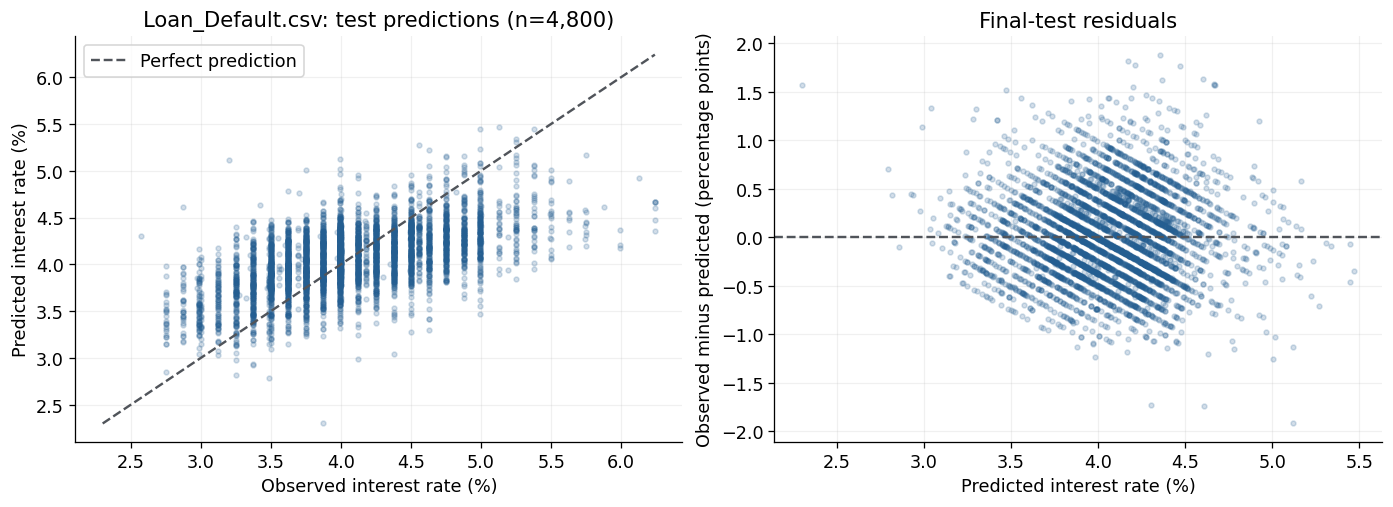

In [17]:
final_model = clone(fitted[chosen_name]).fit(X_dev, y_dev)
prediction = np.asarray(final_model.predict(X_test)).ravel()
baseline = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
final_scores = extra_metrics(y_test, prediction)
baseline_scores = extra_metrics(y_test, baseline)
display(pd.DataFrame([final_scores, baseline_scores], index=[chosen_name, 'Development-mean baseline']))
residuals = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
alpha = 0.8 if len(y_test) < 100 else 0.20
axes[0].scatter(y_test, prediction, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
bounds = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(bounds, bounds, '--', color=GRAY, label='Perfect prediction')
axes[0].set(title=f'{dataset_name}: test predictions (n={len(y_test):,})',
            xlabel=f'Observed {response_axis.lower()}',
            ylabel=f'Predicted {response_axis.lower()}')
axes[0].legend()
axes[1].scatter(prediction, residuals, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
axes[1].axhline(0, linestyle='--', color=GRAY)
axes[1].set(title='Final-test residuals', xlabel=f'Predicted {response_axis.lower()}',
            ylabel=f'Observed minus predicted ({outcome_unit})')
plt.show()
assert np.isfinite(prediction).all()
if dataset_name == 'bank_customers.csv':
    print(f'Negative predicted tenure values: {int((prediction < 0).sum())}/{len(prediction)}; values are not clipped.')
dataset_results.append({'dataset': dataset_name, 'outcome': outcome_label, 'unit': outcome_unit,
    'training n': len(y_train), 'test n': len(y_test), 'model': chosen_name,
    **final_scores, 'baseline RMSE': baseline_scores['RMSE']})

### Dataset conclusions — Loan_Default.csv

Validation selected **Forward selection**. Test RMSE was **0.448 percentage points**, MAE **0.356 percentage points**, and R² **0.338** on **4,800** records. RMSE was **lower** than the development-mean baseline (**0.551 percentage points**).

Forward and backward selection retained **8** and **8** of **9** raw groups. PCR selected **13/13** components (**100.0%** predictor variance), while PLSR selected **13**. Full PCR and OLS validation predictions agreed within **9.77e-15 percentage points**.

The outcome is observed pricing in an eligible subset that excludes nearly all Status 1 records. It does not generalize to missing-rate loans or establish default risk.

## C. bank_customers.csv — independent analysis

The continuous response is **account tenure in years as of September 26, 2026**. Predictors are age at that same date and account type. This is a retrospective account-profile association, not a loan/default model or a causal forecast. Opening date is used only to calculate the response and is excluded from predictors.

**Date and grain decisions.** Exclude future opening dates, missing/unparseable/partial
birth dates, dates after the reference date, opening before birth, and unrecognized account
types. Year-only birth dates are not converted into invented full dates. Eligibility flags
can overlap. Account openings during childhood are retained because custodial accounts are
possible; product eligibility is not documented. Repeated account IDs stay together in
train/validation/test and CV. IDs are group keys, not numeric predictors.

**Interpretation limit.** The original file has only 100 rows and many invalid dates.
The valid subset is very small and not representative of all records. Exact predictive
scores will be unstable; these models demonstrate the weekly methods on genuine observed
account fields. Derived age and tenure share a reference date; their association can
partly reflect the arithmetic constraint that an account cannot predate birth.
SSNs are excluded at read time and identifiers are never displayed.

### C1. Load, audit, and define this dataset’s response

Reconcile the original rows with the eligible modeling population. Features and targets are built from this file alone; no dataset is joined to another.

In [18]:
dataset_name = 'bank_customers.csv'
source_frame = pd.read_csv(DATA_DIR / dataset_name, usecols=lambda name: name != 'SSN')
AS_OF = pd.Timestamp('2026-09-26')
birth_text = source_frame['BirthDate'].astype('string').str.strip()
partial_birth = birth_text.str.fullmatch(r'\d{4}', na=False)
birth = pd.to_datetime(birth_text.mask(partial_birth), format='mixed', errors='coerce')
opened = pd.to_datetime(source_frame['AccountOpened'], format='mixed', errors='coerce')
valid_type = source_frame['AccountType'].isin(['checking', 'savings', 'cd'])
eligible = (birth.notna() & opened.notna() & birth.le(AS_OF) & opened.le(AS_OF)
            & opened.ge(birth) & valid_type)
# Reason flags overlap; the union, not their sum, determines exclusions.
display(pd.Series({'source records': len(source_frame),
    'missing/invalid/partial birth date': birth.isna().sum(),
    'missing/invalid opening date': opened.isna().sum(),
    'future opening date': opened.gt(AS_OF).sum(),
    'opening before exact birth date': opened.lt(birth).sum(),
    'missing/unrecognized account type': (~valid_type).sum(),
    'eligible records': eligible.sum(), 'excluded union': (~eligible).sum()}, name='Bank eligibility audit'))
frame = source_frame.loc[eligible].copy()
frame['age_years'] = (AS_OF - birth.loc[eligible]).dt.days / 365.25
frame['tenure_years'] = (AS_OF - opened.loc[eligible]).dt.days / 365.25
# Repeated AccountID values are conservatively grouped, even though this file
# does not document whether they represent shared accounts or data-quality issues.
frame['_group'] = frame['AccountID'].astype('string')
frame['_group'] = frame['_group'].fillna(pd.Series(
    ['missing_account_' + str(i) for i in frame.index], index=frame.index))
frame = frame.reset_index(drop=True)
groups = frame['_group']
assert len(frame) >= 20
display(frame['AccountType'].value_counts().rename('eligible records').to_frame())
# BirthDate, CustomerID, AccountID, and SSN are never displayed or used as model features.

outcome_label, outcome_unit = 'account tenure', 'years'
response_axis = 'Account tenure (years)'
X = frame[['age_years', 'AccountType']].copy()
y = frame['tenure_years']
numeric, categorical = ['age_years'], ['AccountType']

source records                        100
missing/invalid/partial birth date      3
missing/invalid opening date            1
future opening date                    59
opening before exact birth date         0
missing/unrecognized account type       1
eligible records                       39
excluded union                         61
Name: Bank eligibility audit, dtype: int64

,eligible records
AccountType,
checking,16
savings,15
cd,8


### C2. Reserve evaluation records and inspect training data

The bank file uses account-group splits and group CV; loan files use row splits. Imputation, encoding, scaling, selection, and dimension reduction remain inside training folds. The small bank partitions can have substantially different outcome distributions.

In [19]:
train_index, valid_index, test_index, dev_index, folds = extra_split(X, y, groups, classification=False)
X_train, X_valid, X_test, X_dev = [X.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
y_train, y_valid, y_test, y_dev = [y.iloc[index] for index in [train_index, valid_index, test_index, dev_index]]
split_table = pd.DataFrame({'records': [len(y_train), len(y_valid), len(y_test)],
    'response mean': [y_train.mean(), y_valid.mean(), y_test.mean()]}, index=['training', 'validation', 'test'])
if groups is not None:
    split_table['account groups'] = [groups.iloc[index].nunique() for index in [train_index, valid_index, test_index]]
display(split_table)
display(X_train.isna().mean().mul(100).rename('Training missing (%)').to_frame())

,records,response mean,account groups
training,24,26.3941,21
validation,7,20.7228,7
test,8,18.8433,8


,Training missing (%)
age_years,0.0000
AccountType,0.0000


### C3. Explore this dataset’s training response

Show the response distribution and its relationship with the first continuous predictor. Large-loan samples use translucent points; the bank plot displays every training record. These associations do not establish causation.

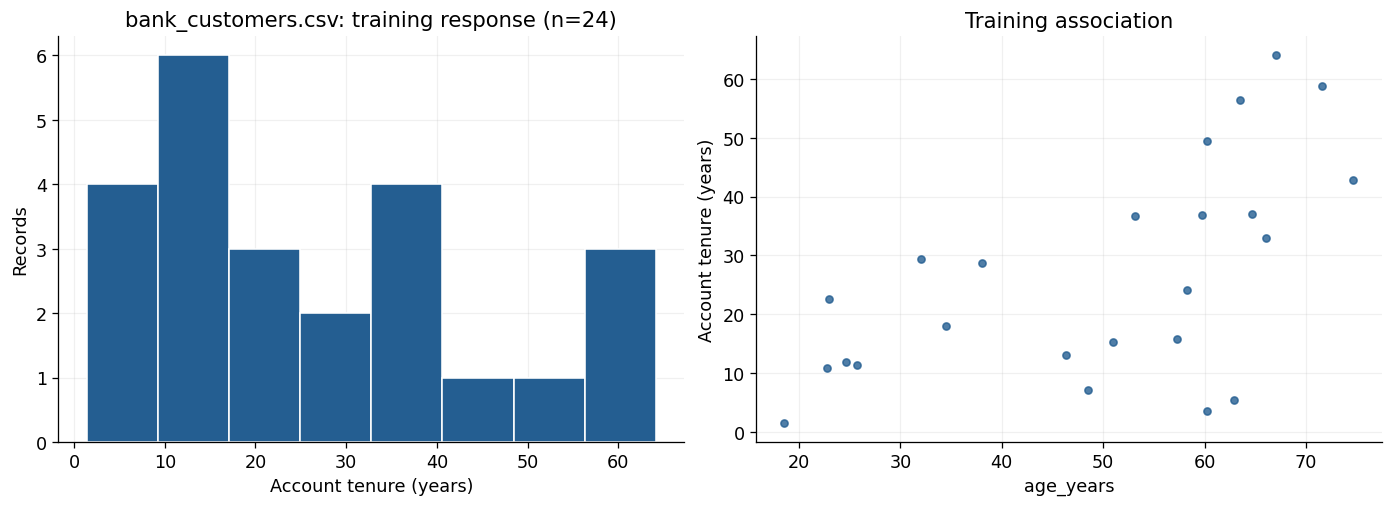

,Training response
count,24.0000
mean,26.3941
std,18.3239
min,1.3990
25%,11.6797
50%,23.3566
75%,36.9103
max,64.1396


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
axes[0].hist(y_train, bins=min(25, max(5, len(y_train)//3)), color=BLUE, edgecolor='white')
axes[0].set(title=f'{dataset_name}: training response (n={len(y_train):,})',
            xlabel=response_axis, ylabel='Records')
axes[1].scatter(X_train[numeric[0]], y_train, s=20 if len(y_train)<100 else 8,
                alpha=0.8 if len(y_train)<100 else 0.2, color=BLUE)
axes[1].set(title='Training association', xlabel=numeric[0],
            ylabel=response_axis)
plt.show()
display(y_train.describe().rename('Training response').to_frame())

### C4. Run forward and backward selection on this dataset

Repeat both greedy searches on raw predictor groups, keeping all levels of a categorical predictor together. Select the best subset size on training CV. Reusing CV folds during subset search can make its minimum error optimistic; validation and test partitions remain separate.

In [21]:
feature_groups = numeric + categorical
cache = {}
def subset_model(names):
    return extra_regressor([name for name in numeric if name in names],
                           [name for name in categorical if name in names])
def subset_score(names):
    key = tuple(name for name in feature_groups if name in names)
    if key not in cache:
        estimator = subset_model(key) if key else DummyRegressor()
        cache[key] = -cross_val_score(estimator,X_train,y_train,cv=folds,
            scoring='neg_root_mean_squared_error',error_score='raise').mean()
    return cache[key]
def greedy_path(direction):
    selected = [] if direction=='forward' else feature_groups.copy()
    rows = [{'groups': selected.copy(),'n_groups':len(selected),'CV RMSE':subset_score(selected)}]
    while (len(selected)<len(feature_groups) if direction=='forward' else len(selected)>1):
        alternatives = []
        for name in feature_groups:
            if direction=='forward' and name not in selected:
                candidate = selected+[name]
            elif direction=='backward' and name in selected:
                candidate = [item for item in selected if item!=name]
            else:
                continue
            alternatives.append((subset_score(candidate),name,candidate))
        score,_,selected = min(alternatives,key=lambda item:(item[0],item[1]))
        rows.append({'groups':selected.copy(),'n_groups':len(selected),'CV RMSE':score})
    return pd.DataFrame(rows)
forward = greedy_path('forward')
backward = greedy_path('backward')
forward_names = forward.loc[forward['CV RMSE'].idxmin(),'groups']
backward_names = backward.loc[backward['CV RMSE'].idxmin(),'groups']
display(forward.drop(columns='groups'))
display(backward.drop(columns='groups'))
display(pd.DataFrame({'feature group':feature_groups,
    'forward selected':[name in forward_names for name in feature_groups],
    'backward selected':[name in backward_names for name in feature_groups]}))

,n_groups,CV RMSE
0,0,18.7634
1,1,15.4453
2,2,19.0801


,n_groups,CV RMSE
0,2,19.0801
1,1,15.4453


,feature group,forward selected,backward selected
0,age_years,True,True
1,AccountType,False,False


### C5. Fit and tune PCR and PLSR on this dataset

PCR chooses directions using X variance; PLSR also uses y. Standardization and the component transform are fitted afresh within each CV fold. The grid respects the smallest training-fold dimension and sample size, which matters especially for the small bank dataset.

In [22]:
dimension = extra_preprocessor(numeric,categorical).fit_transform(X_train).shape[1]
fold_limit = min(min(extra_preprocessor(numeric,categorical).fit_transform(X_train.iloc[fit]).shape[1],
                     len(fit)-1) for fit,_ in folds)
component_grid = list(range(1,min(dimension,fold_limit)+1))
pcr = Pipeline([('prepare',extra_preprocessor(numeric,categorical)),('scale_all',StandardScaler()),
                ('components',PCA(svd_solver='full')),('model',LinearRegression())])
plsr = Pipeline([('prepare',extra_preprocessor(numeric,categorical)),('scale_all',StandardScaler()),
                 ('model',PLSRegression(scale=False,max_iter=2000,tol=1e-7))])
pcr_search = GridSearchCV(pcr,{'components__n_components':component_grid},cv=folds,
    scoring='neg_root_mean_squared_error',error_score='raise',n_jobs=1).fit(X_train,y_train)
pls_search = GridSearchCV(plsr,{'model__n_components':component_grid},cv=folds,
    scoring='neg_root_mean_squared_error',error_score='raise',n_jobs=1).fit(X_train,y_train)
pcr_k = pcr_search.best_params_['components__n_components']
pls_k = pls_search.best_params_['model__n_components']
variance_retained = pcr_search.best_estimator_.named_steps['components'].explained_variance_ratio_.sum()
display(pd.DataFrame({'method':['PCR','PLSR'],'components':[pcr_k,pls_k],
    'CV RMSE':[-pcr_search.best_score_,-pls_search.best_score_]}))
print(f'PCR retains {variance_retained:.1%} of standardized predictor variance.')

,method,components,CV RMSE
0,PCR,2,17.7575
1,PLSR,2,18.3787


PCR retains 85.7% of standardized predictor variance.


### C6. Compare selection, projection, and full OLS

The additive feature set is common to all five approaches. Validation chooses the family after training-CV tuning. No method is required to beat full OLS; retaining most features/components is a legitimate empirical outcome.

,RMSE,MAE,R²
model,,,
Full OLS,19.8199,16.5448,0.2201
PLSR,20.0897,16.7642,0.1988
PCR,20.5660,17.1786,0.1603
Forward selection,21.2418,18.1127,0.1042
Backward selection,21.2418,18.1127,0.1042


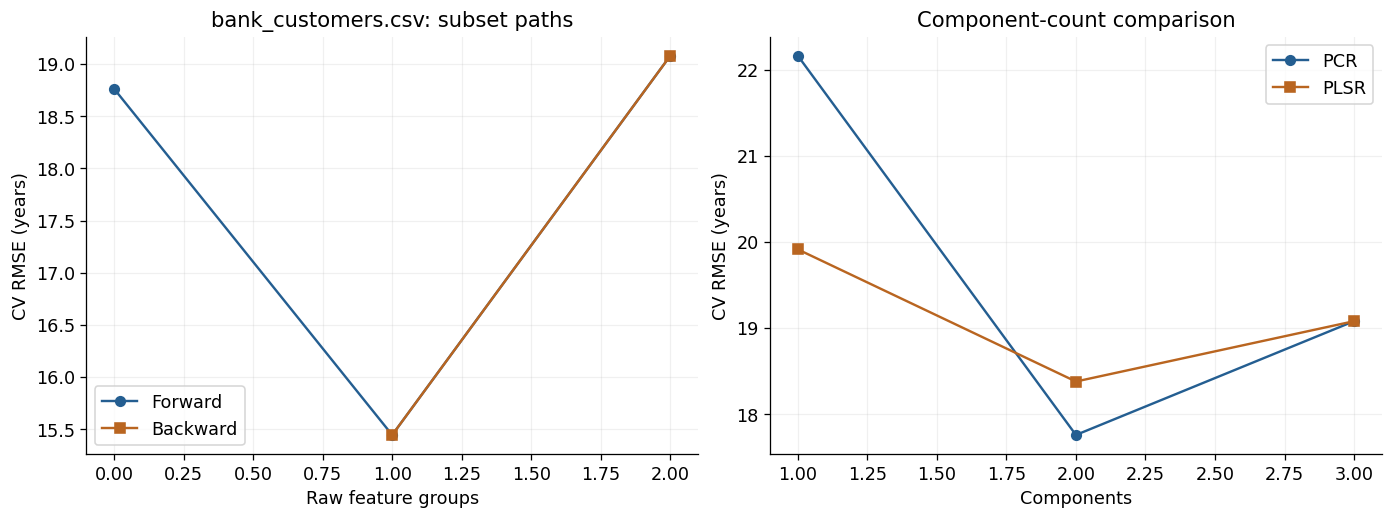

In [23]:
fitted = {
    'Full OLS':subset_model(feature_groups),
    'Forward selection':subset_model(forward_names) if forward_names else DummyRegressor(),
    'Backward selection':subset_model(backward_names),
    'PCR':clone(pcr_search.best_estimator_), 'PLSR':clone(pls_search.best_estimator_)}
rows = []
for name,estimator in fitted.items():
    estimator.fit(X_train,y_train)
    rows.append({'model':name,**extra_metrics(y_valid,estimator.predict(X_valid))})
validation = pd.DataFrame(rows).set_index('model')
display(validation.sort_values('RMSE'))
chosen_name = validation['RMSE'].idxmin()
fig,axes = plt.subplots(1,2,figsize=(12,4.4),layout='constrained')
for name,path,color,marker in [('Forward',forward,BLUE,'o'),('Backward',backward,ORANGE,'s')]:
    ordered = path.sort_values('n_groups')
    axes[0].plot(ordered.n_groups,ordered['CV RMSE'],color=color,marker=marker,label=name)
axes[0].set(title=f'{dataset_name}: subset paths',xlabel='Raw feature groups',ylabel=f'CV RMSE ({outcome_unit})')
axes[0].legend()
for name,search,parameter,color,marker in [('PCR',pcr_search,'param_components__n_components',BLUE,'o'),
                                          ('PLSR',pls_search,'param_model__n_components',ORANGE,'s')]:
    result=pd.DataFrame(search.cv_results_)
    axes[1].plot(result[parameter].astype(int),-result.mean_test_score,color=color,marker=marker,label=name)
axes[1].set(title='Component-count comparison',xlabel='Components',ylabel=f'CV RMSE ({outcome_unit})')
axes[1].legend()
plt.show()
# A fitted-space check, separate from selecting the final method.
full_pcr = clone(pcr).set_params(components__n_components=dimension).fit(X_train,y_train)
pcr_ols_gap = np.max(np.abs(full_pcr.predict(X_valid)-fitted['Full OLS'].predict(X_valid)))
assert pcr_ols_gap<1e-6
method_finding = (f"Forward and backward selection retained **{len(forward_names)}** and "
    f"**{len(backward_names)}** of **{len(feature_groups)}** raw groups. PCR selected **{pcr_k}/{dimension}** "
    f"components (**{variance_retained:.1%}** predictor variance), while PLSR selected **{pls_k}**. "
    f"Full PCR and OLS validation predictions agreed within **{pcr_ols_gap:.2e} {outcome_unit}**.")

### C7. Evaluate and diagnose this dataset’s final model

Freeze the validation-selected family/configuration, refit on development rows, and evaluate on the test partition. Report the mean-only baseline, residuals, and the test sample size. Negative R² is retained when the model underperforms.

,RMSE,MAE,R²
Full OLS,10.8170,8.8571,-0.0825
Development-mean baseline,12.1410,10.3660,-0.3637


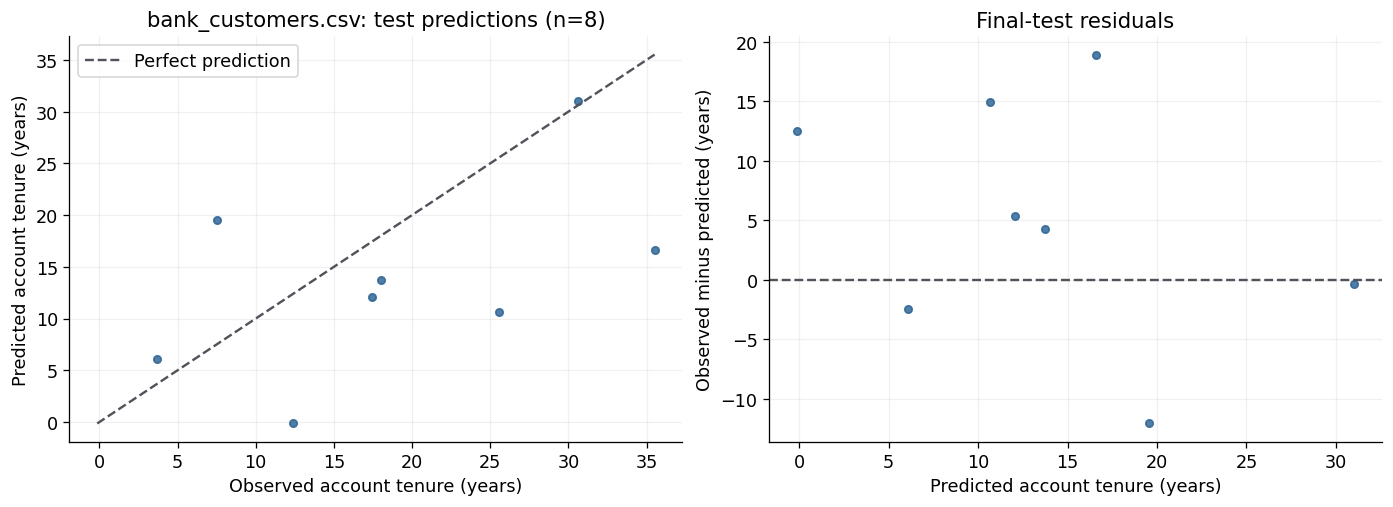

Negative predicted tenure values: 1/8; values are not clipped.


In [24]:
final_model = clone(fitted[chosen_name]).fit(X_dev, y_dev)
prediction = np.asarray(final_model.predict(X_test)).ravel()
baseline = DummyRegressor().fit(X_dev, y_dev).predict(X_test)
final_scores = extra_metrics(y_test, prediction)
baseline_scores = extra_metrics(y_test, baseline)
display(pd.DataFrame([final_scores, baseline_scores], index=[chosen_name, 'Development-mean baseline']))
residuals = y_test.to_numpy() - prediction
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), layout='constrained')
alpha = 0.8 if len(y_test) < 100 else 0.20
axes[0].scatter(y_test, prediction, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
bounds = [min(y_test.min(), prediction.min()), max(y_test.max(), prediction.max())]
axes[0].plot(bounds, bounds, '--', color=GRAY, label='Perfect prediction')
axes[0].set(title=f'{dataset_name}: test predictions (n={len(y_test):,})',
            xlabel=f'Observed {response_axis.lower()}',
            ylabel=f'Predicted {response_axis.lower()}')
axes[0].legend()
axes[1].scatter(prediction, residuals, color=BLUE, alpha=alpha, s=22 if len(y_test)<100 else 9)
axes[1].axhline(0, linestyle='--', color=GRAY)
axes[1].set(title='Final-test residuals', xlabel=f'Predicted {response_axis.lower()}',
            ylabel=f'Observed minus predicted ({outcome_unit})')
plt.show()
assert np.isfinite(prediction).all()
if dataset_name == 'bank_customers.csv':
    print(f'Negative predicted tenure values: {int((prediction < 0).sum())}/{len(prediction)}; values are not clipped.')
dataset_results.append({'dataset': dataset_name, 'outcome': outcome_label, 'unit': outcome_unit,
    'training n': len(y_train), 'test n': len(y_test), 'model': chosen_name,
    **final_scores, 'baseline RMSE': baseline_scores['RMSE']})

### Dataset conclusions — bank_customers.csv

Validation selected **Full OLS**. Test RMSE was **10.817 years**, MAE **8.857 years**, and R² **-0.083** on **8** records. RMSE was **lower** than the development-mean baseline (**12.141 years**).

Forward and backward selection retained **1** and **1** of **2** raw groups. PCR selected **2/3** components (**85.7%** predictor variance), while PLSR selected **2**. Full PCR and OLS validation predictions agreed within **7.11e-15 years**.

Only a small historical, date-valid subset is modeled; account-group separation prevents repeat-account leakage but leaves very few validation/test observations. Scores are descriptive demonstrations, not stable estimates of customer behavior.

**Baseline interpretation:** R² compares predictions with the mean of this particular test set. The fitted baseline uses the development-set mean, so a model can beat that feasible baseline while still having negative test R². Unconstrained OLS can also produce negative tenure; the validity count printed above is retained rather than silently clipping predictions.

## Method references

- [scikit-learn: linear models](https://scikit-learn.org/stable/modules/linear_model.html)
- [scikit-learn: preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html)
- [scikit-learn: feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)
- [scikit-learn: PCR versus PLS](https://scikit-learn.org/stable/auto_examples/cross_decomposition/plot_pcr_vs_pls.html)

Dataset observations in this notebook come from the local CSV files; the links explain methods, not dataset provenance. The original assignment text is preserved above. Its omitted Milestone One rubric/link still needs to be checked before final submission.

### Reconcile coverage across the three datasets

Each row comes from a separately fitted workflow above. Response units and sample sizes are retained to prevent false comparisons between different tasks.

In [25]:
all_dataset_results = pd.DataFrame(dataset_results).set_index('dataset')
assert set(all_dataset_results.index) == {
    'accepted_2007_to_2018Q4.csv','Loan_Default.csv','bank_customers.csv'}
with pd.option_context('display.max_columns',None,'display.max_colwidth',75):
    display(all_dataset_results)

,outcome,unit,training n,test n,model,RMSE,MAE,R²,baseline RMSE
dataset,,,,,,,,,
accepted_2007_to_2018Q4.csv,issued interest rate,percentage points,14400,4800,Forward selection,3.0842,2.4406,0.4850,4.2988
Loan_Default.csv,observed interest rate,percentage points,14400,4800,Forward selection,0.4482,0.3558,0.3376,0.5510
bank_customers.csv,account tenure,years,24,8,Full OLS,10.8170,8.8571,-0.0825,12.1410


## Overall conclusions

- **accepted_2007_to_2018Q4.csv**: Forward selection; test RMSE **3.084 percentage points**, MAE **2.441 percentage points**, R² **0.485**, test n = **4,800**. Development-mean baseline RMSE: **4.299 percentage points**.
- **Loan_Default.csv**: Forward selection; test RMSE **0.448 percentage points**, MAE **0.356 percentage points**, R² **0.338**, test n = **4,800**. Development-mean baseline RMSE: **0.551 percentage points**.
- **bank_customers.csv**: Full OLS; test RMSE **10.817 years**, MAE **8.857 years**, R² **-0.083**, test n = **8**. Development-mean baseline RMSE: **12.141 years**.

Each dataset now has its own full application of this week's required methods. LendingClub models issued rates in a 2015 cohort; Loan_Default models observed rates in a heavily selected subset; bank_customers models historical account tenure. Their errors use different populations and, for the bank file, different units. The small bank holdout is a method demonstration, not a reliable performance claim. The dataset-specific conclusions above explain the observed selection, shrinkage, or component tradeoff. No result establishes causality or future-cohort validity.